<a href="https://colab.research.google.com/github/budennovsk/testovoe_Media_108/blob/budennovsk%2Fpythonanywere/testovoe_108.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
!pip install catboost
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.5 MB/s eta 0:00:00


In [79]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
import numpy as np

import seaborn as sns




In [14]:
# Загружаем файл
file_path = '/content/drive/MyDrive/Colab Notebooks/zvezda/Server_zvezda/Dataset/logs_api_test.tsv'
# Загружаем файл с разделителем табуляции
df = pd.read_csv(file_path, sep='\t',low_memory=False)

# Просмотрим первые несколько строк





In [24]:
df['ym:s:goalsID']

,ym:s:goalsID
0,[]
1,[]
2,[]
3,[]
4,[]
...,...
13599,[]
13600,[]
13601,[]
13602,[291725831]


In [29]:

# Преобразуем каждый элемент строки в список и извлекаем уникальные числа
unique_ints = set()

for item in df['ym:s:goalsID']:
    # Преобразуем строку в список
    nums = ast.literal_eval(item)
    # Добавляем все числа из списка в set (он автоматически удаляет дубликаты)
    unique_ints.update(nums)

# Преобразуем set обратно в список и выводим
unique_list = list(unique_ints)
print(len(unique_list))
print(unique_list)

31
[238890752, 61661443, 291725831, 310638089, 310638090, 310638091, 310638476, 310638482, 310637587, 310637588, 310637586, 310637949, 333377823, 333755569, 310638392, 333757634, 346867403, 346867404, 312459725, 310638416, 168147670, 27462749, 305143283, 310638324, 305143284, 238890740, 310637691, 310637692, 310637693, 310637950, 310637951]


In [46]:
# Считаем, сколько раз каждое уникальное значение встречается в каждой строке
goal_counts = {goal: 0 for goal in unique_list}  # Инициализируем словарь для подсчета

for item in df['ym:s:goalsID']:
    nums = ast.literal_eval(item)
    for goal in unique_list:
        if goal in nums:
            goal_counts[goal] += 1
# Сортируем словарь по значениям (по убыванию)
sorted_goal_counts = dict(sorted(goal_counts.items(), key=lambda item: item[1], reverse=True))

print(sorted_goal_counts)

{291725831: 313, 346867403: 250, 346867404: 250, 310638476: 243, 168147670: 187, 305143283: 101, 310637587: 84, 310638482: 64, 310638090: 55, 333757634: 46, 310637692: 42, 310638324: 39, 333755569: 34, 310638089: 15, 310638091: 15, 310637691: 14, 310637693: 14, 333377823: 10, 310638392: 9, 310638416: 7, 312459725: 6, 61661443: 5, 310637588: 4, 310637586: 4, 238890752: 2, 310637950: 2, 310637949: 1, 27462749: 1, 305143284: 1, 238890740: 1, 310637951: 1}


0:	learn: 0.4423019	test: 0.4431714	best: 0.4431714 (0)	total: 357ms	remaining: 2m 58s
100:	learn: 0.0037596	test: 0.0081139	best: 0.0077661 (59)	total: 11.9s	remaining: 47.1s
200:	learn: 0.0029100	test: 0.0083832	best: 0.0077661 (59)	total: 24.7s	remaining: 36.7s
300:	learn: 0.0022128	test: 0.0092722	best: 0.0077661 (59)	total: 37.6s	remaining: 24.9s
400:	learn: 0.0018020	test: 0.0100392	best: 0.0077661 (59)	total: 50.2s	remaining: 12.4s
499:	learn: 0.0014836	test: 0.0105940	best: 0.0077661 (59)	total: 1m 4s	remaining: 0us

bestTest = 0.007766070076
bestIteration = 59

Shrink model to first 60 iterations.
ROC AUC: 0.9997
PR AUC: 0.9882
Confusion Matrix:
[[2658    0]
 [   8   55]]


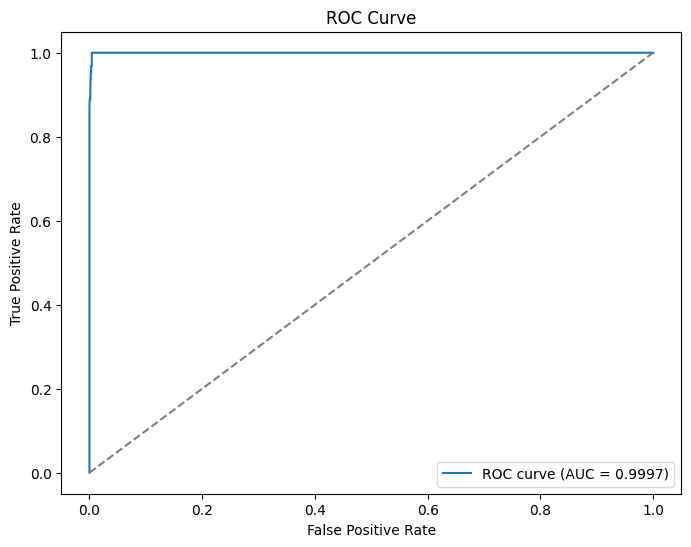

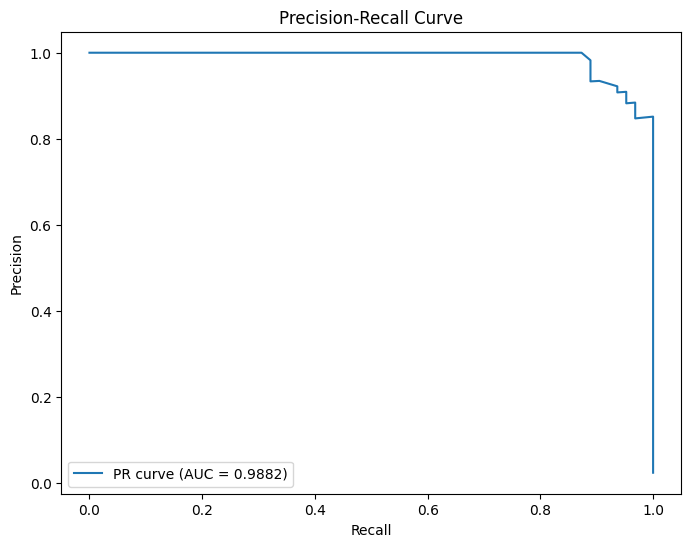

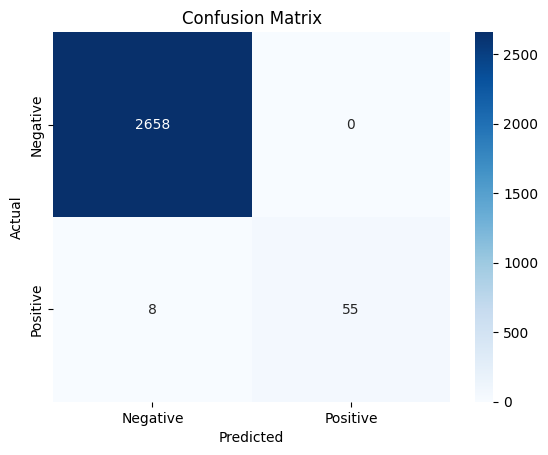

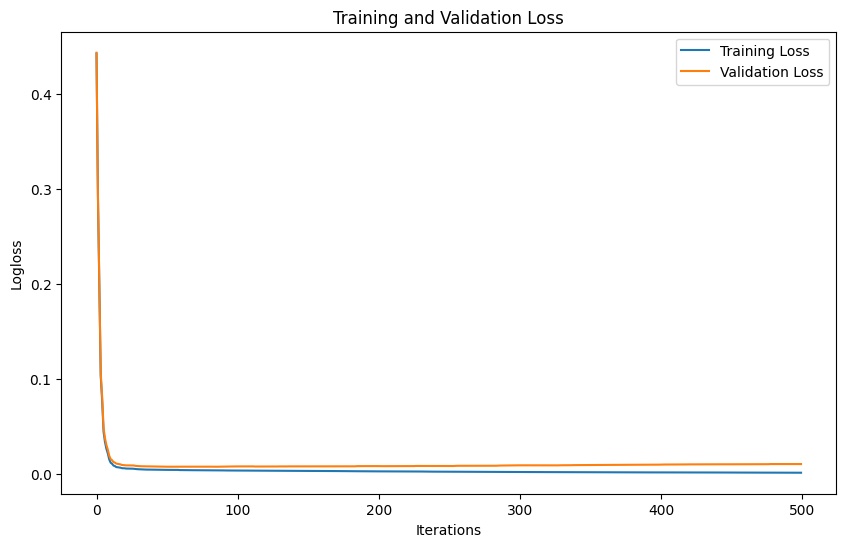

In [83]:


# Предположим, что df уже загружен и столбец 'ym:s:goalsID' существует

# Преобразуем целевой столбец в бинарный формат
df['target'] = df['ym:s:goalsID'].apply(lambda x: 1 if '291725831' in x else 0)

# Разделяем данные на признаки и цель
# X = df.drop(columns=['target','ym:s:goalsPrice','ym:s:endURL','ym:s:pageViews','ym:s:offlineCallTag','ym:s:goalsID'])

X = df.drop(columns=['target'])
y = df['target']
# Перемешиваем таргет
# y_shuffled = np.random.permutation(y)

# Находим все столбцы с типом object (строковые данные)
cat_features = X.select_dtypes(include=['object']).columns.tolist()
X[cat_features] = X[cat_features].fillna("missing")
# Разделяем данные на тренировочную и тестовую выборки с учётом стратификации
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Инициализируем модель CatBoost
model = CatBoostClassifier(iterations=500, depth=2, learning_rate=0.1, loss_function='Logloss', cat_features=cat_features, random_seed=42)

# Обучаем модель
model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)

# Прогнозы
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Оценка модели

# ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# PR AUC
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR AUC: {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Построение ROC кривой
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Построение Precision-Recall кривой
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

# Построение confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Построение графика обучения
plt.figure(figsize=(10, 6))
plt.plot(model.get_evals_result()['learn']['Logloss'], label='Training Loss')
plt.plot(model.get_evals_result()['validation']['Logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [81]:
# Получаем важность признаков
feature_importances = model.get_feature_importance()

# Получаем имена признаков
feature_names = X.columns

# Создаем DataFrame с признаками и их важностью
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Сортируем по важности и выводим 20 лучших признаков
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

print(top_20_features)


                                               Feature  Importance
40                                        ym:s:visitID    7.873960
39                                  ym:s:visitDuration    5.710051
37                                ym:s:regionCountryID    5.255124
33                                      ym:s:pageViews    4.427079
343                             ym:s:windowClientWidth    4.137443
30                          ym:s:lastsignTrafficSource    3.488572
287                                ym:s:clientTimeZone    3.409561
326                          ym:s:physicalScreenHeight    2.828151
9    ym:s:cross_device_last_yandex_direct_clickTraf...    2.648923
12                                           ym:s:date    2.535003
36                                  ym:s:regionCountry    2.513018
342                            ym:s:windowClientHeight    2.218189
306                                  ym:s:screenFormat    1.926126
302                               ym:s:operatingSystem    1.81

In [68]:
X_1 = X.copy()
X_1['target']= y.values
X_1[['target','ym:s:goalsPrice','ym:s:endURL','ym:s:pageViews']].to_excel('1.xlsx')

In [102]:
import category_encoders as ce
import pandas as pd

# Преобразуем категориальные признаки с помощью CatBoostEncoder
X = df.drop(columns=['ym:s:goalsID', 'target'])
y = df['target']

# Указываем, какие признаки являются категориальными
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Инициализируем CatBoostEncoder
encoder = ce.CatBoostEncoder(cols=cat_features)

# Применяем CatBoostEncoder для категориальных признаков
X_encoded = encoder.fit_transform(X, y)
# Заменяем NaN значения на медиану для предотвращения ошибки
X_encoded = X_encoded.fillna(X_encoded.median())

# Убираем признаки с нулевой дисперсией (константные столбцы)
X_encoded = X_encoded.loc[:, X_encoded.nunique() > 1]


# Вычисляем корреляцию для всех признаков
correlation = X_encoded.corrwith(y)

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.5)
high_correlation = correlation[abs(correlation) > 0.5]
print(high_correlation)


ym:s:endURL                        0.810762
ym:s:goalsDateTime                 0.597024
ym:s:goalsOrder                    0.626060
ym:s:goalsPrice                    0.596059
ym:s:goalsSerialNumber             0.630173
ym:s:startURL                      0.731727
ym:s:offlineCallFirstTimeCaller    0.591915
ym:s:offlineCallHoldDuration       0.591915
ym:s:offlineCallMissed             0.591915
ym:s:offlineCallTag                0.591915
ym:s:offlineCallTalkDuration       0.591915
ym:s:offlineCallURL                0.591915
dtype: float64


In [101]:
# Вычисляем корреляцию Спирмена
correlation_spearman = X_encoded.corrwith(y, method='spearman')

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.5)
high_correlation_spearman = correlation_spearman[abs(correlation_spearman) > 0.1]
print(high_correlation_spearman)

ym:s:endURL                        0.221006
ym:s:goalsDateTime                 0.249397
ym:s:goalsOrder                    0.251621
ym:s:goalsPrice                    0.250443
ym:s:goalsSerialNumber             0.252340
ym:s:pageViews                     0.147838
ym:s:startURL                      0.211261
ym:s:visitDuration                 0.117414
ym:s:offlineCallFirstTimeCaller    0.250179
ym:s:offlineCallHoldDuration       0.250179
ym:s:offlineCallMissed             0.250179
ym:s:offlineCallTag                0.250179
ym:s:offlineCallTalkDuration       0.250179
ym:s:offlineCallURL                0.250179
dtype: float64


In [100]:
# Вычисляем корреляцию Кендалла
correlation_kendall = X_encoded.corrwith(y, method='kendall')

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.9)
high_correlation_kendall = correlation_kendall[abs(correlation_kendall) > 0.1]
print(high_correlation_kendall)

ym:s:endURL                        0.182070
ym:s:goalsDateTime                 0.204005
ym:s:goalsOrder                    0.205464
ym:s:goalsPrice                    0.204494
ym:s:goalsSerialNumber             0.206048
ym:s:pageViews                     0.142317
ym:s:startURL                      0.174200
ym:s:visitDuration                 0.101858
ym:s:offlineCallFirstTimeCaller    0.204278
ym:s:offlineCallHoldDuration       0.204278
ym:s:offlineCallMissed             0.204278
ym:s:offlineCallTag                0.204278
ym:s:offlineCallTalkDuration       0.204278
ym:s:offlineCallURL                0.204278
dtype: float64


In [97]:
from sklearn.feature_selection import mutual_info_classif

# Рассчитываем взаимную информацию для признаков относительно целевой переменной
mutual_info = mutual_info_classif(X_encoded, y)

# Создаем DataFrame с результатами
mutual_info_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'mutual_info': mutual_info
})

# Сортируем по взаимной информации
mutual_info_df = mutual_info_df.sort_values(by='mutual_info', ascending=False)

# Выводим 10 наиболее важных признаков
print(mutual_info_df.head(10))


                             feature  mutual_info
22            ym:s:goalsSerialNumber     0.072747
20                   ym:s:goalsOrder     0.071124
19                ym:s:goalsDateTime     0.068689
15                       ym:s:endURL     0.067695
294              ym:s:offlineCallTag     0.067515
291  ym:s:offlineCallFirstTimeCaller     0.067453
296              ym:s:offlineCallURL     0.067389
295     ym:s:offlineCallTalkDuration     0.067372
292     ym:s:offlineCallHoldDuration     0.067173
293           ym:s:offlineCallMissed     0.067105


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Сортируем по значению важности
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))
